In [ ]:
# OmniEdge Customer Churn Command Center Analysis

This notebook analyzes churn modeling, risk segmentation, revenue-at-risk exposure, and retention strategy outputs generated by the Customer Churn Command Center pipeline.

## Objectives
- Evaluate churn model performance
- Profile customer risk segments
- Quantify financial exposure
- Analyze retention priority logic
- Surface the highest-value intervention opportunities
- Produce executive-level customer retention insights

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path("/Users/6ixbio/Downloads/customer-churn-command-center")
PROCESSED_DIR = BASE_DIR / "data" / "processed"

feature_matrix = pd.read_csv(PROCESSED_DIR / "feature_matrix.csv")
training_auc_summary = pd.read_csv(PROCESSED_DIR / "training_auc_summary.csv")
model_performance_metrics = pd.read_csv(PROCESSED_DIR / "model_performance_metrics.csv")
confusion_matrix_summary = pd.read_csv(PROCESSED_DIR / "confusion_matrix_summary.csv")
best_model_selection = pd.read_csv(PROCESSED_DIR / "best_model_selection.csv")

customer_predictions = pd.read_csv(PROCESSED_DIR / "customer_predictions.csv")
customer_risk_segments = pd.read_csv(PROCESSED_DIR / "customer_risk_segments.csv")
revenue_at_risk_summary = pd.read_csv(PROCESSED_DIR / "revenue_at_risk_summary.csv")

retention_action_plan = pd.read_csv(PROCESSED_DIR / "retention_action_plan.csv")
high_value_at_risk_customers = pd.read_csv(PROCESSED_DIR / "high_value_at_risk_customers.csv")
retention_playbook_by_segment = pd.read_csv(PROCESSED_DIR / "retention_playbook_by_segment.csv")
top_retention_playbooks = pd.read_csv(PROCESSED_DIR / "top_retention_playbooks.csv")

summary_text = (PROCESSED_DIR / "executive_retention_summary.txt").read_text()

print("feature_matrix:", feature_matrix.shape)
print("training_auc_summary:", training_auc_summary.shape)
print("model_performance_metrics:", model_performance_metrics.shape)
print("customer_predictions:", customer_predictions.shape)
print("retention_action_plan:", retention_action_plan.shape)

feature_matrix: (7043, 14)
training_auc_summary: (3, 5)
model_performance_metrics: (3, 6)
customer_predictions: (7043, 12)
retention_action_plan: (7043, 13)


In [ ]:
## 1. Data Quality and Output Validation
Validate the processed outputs before interpreting the business results.

In [2]:
def profile_dataframe(df: pd.DataFrame, name: str) -> pd.DataFrame:
    out = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "null_count": df.isna().sum().values,
        "null_pct": (df.isna().mean() * 100).round(2).values,
        "distinct_count": df.nunique(dropna=False).values,
    })
    out.insert(0, "dataset", name)
    return out

dq_profile = pd.concat([
    profile_dataframe(feature_matrix, "feature_matrix"),
    profile_dataframe(customer_predictions, "customer_predictions"),
    profile_dataframe(retention_action_plan, "retention_action_plan"),
    profile_dataframe(customer_risk_segments, "customer_risk_segments"),
], ignore_index=True)

dq_profile

,dataset,column,dtype,null_count,null_pct,distinct_count
0,feature_matrix,customerID,object,0,0.0,7043
1,feature_matrix,tenure,int64,0,0.0,73
2,feature_matrix,tenure_band,object,0,0.0,4
3,feature_matrix,MonthlyCharges,float64,0,0.0,1585
4,feature_matrix,monthly_charge_band,object,0,0.0,4
5,feature_matrix,TotalCharges,float64,0,0.0,6531
6,feature_matrix,Contract,object,0,0.0,3
7,feature_matrix,contract_risk_band,object,0,0.0,3
8,feature_matrix,service_count,int64,0,0.0,8
9,feature_matrix,has_fiber,int64,0,0.0,2


In [ ]:
## 2. Model Performance Comparison
Compare the candidate churn models and confirm the selected production model.

In [3]:
training_auc_summary

,model_name,train_auc,test_auc,train_rows,test_rows
0,logistic_regression,0.8512,0.8416,5634,1409
1,random_forest,0.9328,0.8435,5634,1409
2,xgboost,0.9421,0.8406,5634,1409


In [4]:
model_performance_metrics.sort_values("roc_auc", ascending=False)

,model_name,roc_auc,precision,recall,f1_score,accuracy
0,random_forest,0.8435,0.6507,0.5080,0.5706,0.7970
1,logistic_regression,0.8416,0.6497,0.5107,0.5719,0.7970
2,xgboost,0.8406,0.6556,0.5294,0.5858,0.8013


In [5]:
confusion_matrix_summary

,model_name,true_negative,false_positive,false_negative,true_positive
0,logistic_regression,932,103,183,191
1,random_forest,933,102,184,190
2,xgboost,931,104,176,198


In [6]:
best_model_selection

,selected_model,selection_basis
0,random_forest,Highest ROC AUC on holdout test set


In [ ]:
## 3. Customer Risk Segmentation
Profile the predicted churn-risk distribution across the customer base.

In [7]:
customer_risk_segments

,predicted_risk_band,customer_count,avg_churn_probability,total_predicted_revenue_at_risk,avg_monthly_charges
0,High,1111,0.611490,648246.48,79.174617
1,Moderate,1562,0.372796,488107.26,69.636236
2,Critical,356,0.817451,290983.35,83.275702
3,Low,4014,0.080900,253922.44,57.233595


In [8]:
risk_band_counts = (
    customer_predictions["predicted_risk_band"]
    .value_counts()
    .rename_axis("predicted_risk_band")
    .reset_index(name="customer_count")
)

risk_band_counts

,predicted_risk_band,customer_count
0,Low,4014
1,Moderate,1562
2,High,1111
3,Critical,356


In [9]:
customer_predictions[[
    "customerID",
    "predicted_churn_probability",
    "predicted_risk_band",
    "predicted_revenue_at_risk",
    "retention_priority_score"
]].sort_values("retention_priority_score", ascending=False).head(10)

,customerID,predicted_churn_probability,predicted_risk_band,predicted_revenue_at_risk,retention_priority_score
2208,7216-EWTRS,0.910483,Critical,1101.32,1101.32
6482,5419-JPRRN,0.902265,Critical,1098.42,1098.42
1026,4822-RVYBB,0.882626,Critical,1065.51,1065.51
1704,0107-YHINA,0.883417,Critical,1057.45,1057.45
905,0781-LKXBR,0.871568,Critical,1051.11,1051.11
6232,9681-OXGVC,0.871278,Critical,1050.76,1050.76
6365,8884-ADFVN,0.858336,Critical,1050.09,1050.09
5,9305-CDSKC,0.876982,Critical,1048.70,1048.70
2631,6861-XWTWQ,0.877272,Critical,1044.83,1044.83
6215,2446-BEGGB,0.884785,Critical,1043.16,1043.16


In [ ]:
## 4. Revenue-at-Risk Analysis
Quantify the financial exposure associated with churn risk.

In [10]:
revenue_at_risk_summary.T.rename(columns={0: "value"})

,value
total_customers_scored,7043
total_estimated_annual_revenue,5473399.2
total_predicted_revenue_at_risk,1681259.53
high_risk_customers,1467
high_risk_revenue_at_risk,939229.83
selected_model,random_forest


In [11]:
risk_revenue_summary = (
    customer_predictions
    .groupby("predicted_risk_band", as_index=False)
    .agg(
        customer_count=("customerID", "count"),
        total_predicted_revenue_at_risk=("predicted_revenue_at_risk", "sum"),
        avg_predicted_revenue_at_risk=("predicted_revenue_at_risk", "mean"),
        avg_churn_probability=("predicted_churn_probability", "mean"),
    )
    .sort_values("total_predicted_revenue_at_risk", ascending=False)
)

risk_revenue_summary

,predicted_risk_band,customer_count,total_predicted_revenue_at_risk,avg_predicted_revenue_at_risk,avg_churn_probability
1,High,1111,648246.48,583.480180,0.611490
3,Moderate,1562,488107.26,312.488643,0.372796
0,Critical,356,290983.35,817.368961,0.817451
2,Low,4014,253922.44,63.259203,0.080900


In [ ]:
## 5. Retention Action Analysis
Review how the system converts risk predictions into practical customer actions.

In [12]:
retention_action_plan.head(10)

,customerID,Contract,tenure,MonthlyCharges,estimated_annual_revenue,predicted_churn_probability,predicted_risk_band,predicted_revenue_at_risk,retention_priority_score,priority_tier,customer_value_band,recommended_offer_type,retention_action
0,7590-VHVEG,Month-to-month,1,29.85,358.2,0.499816,Moderate,179.03,179.03,P3,Standard Value,Customer education / support touchpoint,Send onboarding reinforcement and support chec...
1,5575-GNVDE,One year,34,56.95,683.4,0.023608,Low,16.13,16.13,P4,Medium Value,No immediate offer,Monitor only
2,3668-QPYBK,Month-to-month,2,53.85,646.2,0.465868,Moderate,301.04,301.04,P3,Medium Value,Customer education / support touchpoint,Send onboarding reinforcement and support chec...
3,7795-CFOCW,One year,45,42.30,507.6,0.030421,Low,15.44,15.44,P4,Standard Value,No immediate offer,Monitor only
4,9237-HQITU,Month-to-month,2,70.70,848.4,0.634750,High,538.52,538.52,P2,Medium Value,No immediate offer,Offer discount or bundle upgrade to reduce chu...
5,9305-CDSKC,Month-to-month,8,99.65,1195.8,0.876982,Critical,1048.70,1048.70,P1,High Value,Contract conversion incentive,Immediate retention outreach with contract con...
6,1452-KIOVK,Month-to-month,22,89.10,1069.2,0.429901,Moderate,459.65,459.65,P2,High Value,Customer education / support touchpoint,Monitor and enroll in nurture retention journey
7,6713-OKOMC,Month-to-month,10,29.75,357.0,0.225990,Low,80.68,80.68,P4,Standard Value,No immediate offer,Monitor only
8,7892-POOKP,Month-to-month,28,104.80,1257.6,0.629057,High,791.10,791.10,P1,High Value,Discount / pricing support,Offer discount or bundle upgrade to reduce chu...
9,6388-TABGU,One year,62,56.15,673.8,0.026010,Low,17.53,17.53,P4,Medium Value,No immediate offer,Monitor only


In [13]:
priority_counts = (
    retention_action_plan["priority_tier"]
    .value_counts()
    .rename_axis("priority_tier")
    .reset_index(name="customer_count")
)

priority_counts

,priority_tier,customer_count
0,P4,3725
1,P3,1574
2,P2,1345
3,P1,399


In [14]:
offer_mix = (
    retention_action_plan
    .groupby(["predicted_risk_band", "recommended_offer_type"], as_index=False)
    .agg(customer_count=("customerID", "count"))
    .sort_values("customer_count", ascending=False)
)

offer_mix.head(15)

,predicted_risk_band,recommended_offer_type,customer_count
3,Low,No immediate offer,4014
4,Moderate,Customer education / support touchpoint,1562
1,High,Discount / pricing support,721
2,High,No immediate offer,390
0,Critical,Contract conversion incentive,356


In [ ]:
## 6. High-Value At-Risk Customers
Identify the highest-priority customers for proactive intervention.

In [15]:
high_value_at_risk_customers.head(15)

,customerID,Contract,tenure,MonthlyCharges,estimated_annual_revenue,predicted_churn_probability,predicted_risk_band,predicted_revenue_at_risk,retention_priority_score,priority_tier,customer_value_band,recommended_offer_type,retention_action
0,7216-EWTRS,Month-to-month,1,100.80,1209.6,0.910483,Critical,1101.32,1101.32,P1,High Value,Contract conversion incentive,Immediate retention outreach with contract con...
1,5419-JPRRN,Month-to-month,1,101.45,1217.4,0.902265,Critical,1098.42,1098.42,P1,High Value,Contract conversion incentive,Immediate retention outreach with contract con...
2,4822-RVYBB,Month-to-month,8,100.60,1207.2,0.882626,Critical,1065.51,1065.51,P1,High Value,Contract conversion incentive,Immediate retention outreach with contract con...
3,0107-YHINA,Month-to-month,1,99.75,1197.0,0.883417,Critical,1057.45,1057.45,P1,High Value,Contract conversion incentive,Immediate retention outreach with contract con...
4,0781-LKXBR,Month-to-month,9,100.50,1206.0,0.871568,Critical,1051.11,1051.11,P1,High Value,Contract conversion incentive,Immediate retention outreach with contract con...
5,9681-OXGVC,Month-to-month,5,100.50,1206.0,0.871278,Critical,1050.76,1050.76,P1,High Value,Contract conversion incentive,Immediate retention outreach with contract con...
6,8884-ADFVN,Month-to-month,7,101.95,1223.4,0.858336,Critical,1050.09,1050.09,P1,High Value,Contract conversion incentive,Immediate retention outreach with contract con...
7,9305-CDSKC,Month-to-month,8,99.65,1195.8,0.876982,Critical,1048.70,1048.70,P1,High Value,Contract conversion incentive,Immediate retention outreach with contract con...
8,6861-XWTWQ,Month-to-month,7,99.25,1191.0,0.877272,Critical,1044.83,1044.83,P1,High Value,Contract conversion incentive,Immediate retention outreach with contract con...
9,2446-BEGGB,Month-to-month,6,98.25,1179.0,0.884785,Critical,1043.16,1043.16,P1,High Value,Contract conversion incentive,Immediate retention outreach with contract con...


In [16]:
top_priority_customers = high_value_at_risk_customers.sort_values(
    "retention_priority_score", ascending=False
).head(20)

top_priority_customers[[
    "customerID",
    "predicted_risk_band",
    "customer_value_band",
    "predicted_revenue_at_risk",
    "retention_priority_score",
    "recommended_offer_type",
    "retention_action"
]]

,customerID,predicted_risk_band,customer_value_band,predicted_revenue_at_risk,retention_priority_score,recommended_offer_type,retention_action
0,7216-EWTRS,Critical,High Value,1101.32,1101.32,Contract conversion incentive,Immediate retention outreach with contract con...
1,5419-JPRRN,Critical,High Value,1098.42,1098.42,Contract conversion incentive,Immediate retention outreach with contract con...
2,4822-RVYBB,Critical,High Value,1065.51,1065.51,Contract conversion incentive,Immediate retention outreach with contract con...
3,0107-YHINA,Critical,High Value,1057.45,1057.45,Contract conversion incentive,Immediate retention outreach with contract con...
4,0781-LKXBR,Critical,High Value,1051.11,1051.11,Contract conversion incentive,Immediate retention outreach with contract con...
5,9681-OXGVC,Critical,High Value,1050.76,1050.76,Contract conversion incentive,Immediate retention outreach with contract con...
6,8884-ADFVN,Critical,High Value,1050.09,1050.09,Contract conversion incentive,Immediate retention outreach with contract con...
7,9305-CDSKC,Critical,High Value,1048.70,1048.70,Contract conversion incentive,Immediate retention outreach with contract con...
8,6861-XWTWQ,Critical,High Value,1044.83,1044.83,Contract conversion incentive,Immediate retention outreach with contract con...
9,2446-BEGGB,Critical,High Value,1043.16,1043.16,Contract conversion incentive,Immediate retention outreach with contract con...


In [ ]:
## 7. Retention Playbook Analysis
Review segment-level retention strategies and modeled revenue concentration.

In [17]:
retention_playbook_by_segment.head(15)

,predicted_risk_band,customer_value_band,recommended_offer_type,retention_action,customer_count,total_revenue_at_risk,avg_monthly_charges,avg_churn_probability
0,Critical,High Value,Contract conversion incentive,Immediate retention outreach with contract con...,196,178588.95,92.905357,0.816880
1,Critical,Medium Value,Contract conversion incentive,High-touch onboarding recovery and service review,125,91312.34,73.654800,0.826927
2,Critical,Medium Value,Contract conversion incentive,Immediate retention outreach with contract con...,22,16922.33,81.256818,0.788985
3,Critical,Standard Value,Contract conversion incentive,High-touch onboarding recovery and service review,13,4159.73,34.015385,0.783116
4,High,High Value,Discount / pricing support,Offer discount or bundle upgrade to reduce chu...,525,367471.86,94.957810,0.614807
5,High,Medium Value,No immediate offer,Offer discount or bundle upgrade to reduce chu...,246,123411.35,68.449390,0.608245
6,High,Medium Value,Discount / pricing support,Offer discount or bundle upgrade to reduce chu...,192,115190.67,78.799740,0.634340
7,High,Standard Value,No immediate offer,Offer discount or bundle upgrade to reduce chu...,144,39657.61,39.817014,0.577214
8,High,High Value,Discount / pricing support,Proactive outreach with pricing/value reinforc...,4,2514.99,102.100000,0.512862
9,Low,High Value,No immediate offer,Monitor only,1048,131789.96,99.200095,0.104554


In [18]:
top_retention_playbooks

,predicted_risk_band,customer_value_band,recommended_offer_type,retention_action,customer_count,total_revenue_at_risk,avg_monthly_charges,avg_churn_probability
0,High,High Value,Discount / pricing support,Offer discount or bundle upgrade to reduce chu...,525,367471.86,94.957810,0.614807
1,Moderate,High Value,Customer education / support touchpoint,Monitor and enroll in nurture retention journey,594,253920.94,96.812542,0.369150
2,Critical,High Value,Contract conversion incentive,Immediate retention outreach with contract con...,196,178588.95,92.905357,0.816880
3,Low,High Value,No immediate offer,Monitor only,1048,131789.96,99.200095,0.104554
4,High,Medium Value,No immediate offer,Offer discount or bundle upgrade to reduce chu...,246,123411.35,68.449390,0.608245


In [19]:
playbook_summary = (
    retention_playbook_by_segment
    .groupby("recommended_offer_type", as_index=False)
    .agg(
        total_customer_count=("customer_count", "sum"),
        total_revenue_at_risk=("total_revenue_at_risk", "sum"),
        avg_churn_probability=("avg_churn_probability", "mean"),
    )
    .sort_values("total_revenue_at_risk", ascending=False)
)

playbook_summary

,recommended_offer_type,total_customer_count,total_revenue_at_risk,avg_churn_probability
1,Customer education / support touchpoint,1562,488107.26,0.383547
2,Discount / pricing support,721,485177.52,0.587336
3,No immediate offer,4404,416991.40,0.287873
0,Contract conversion incentive,356,290983.35,0.803977


In [ ]:
## 8. Analytical Visuals

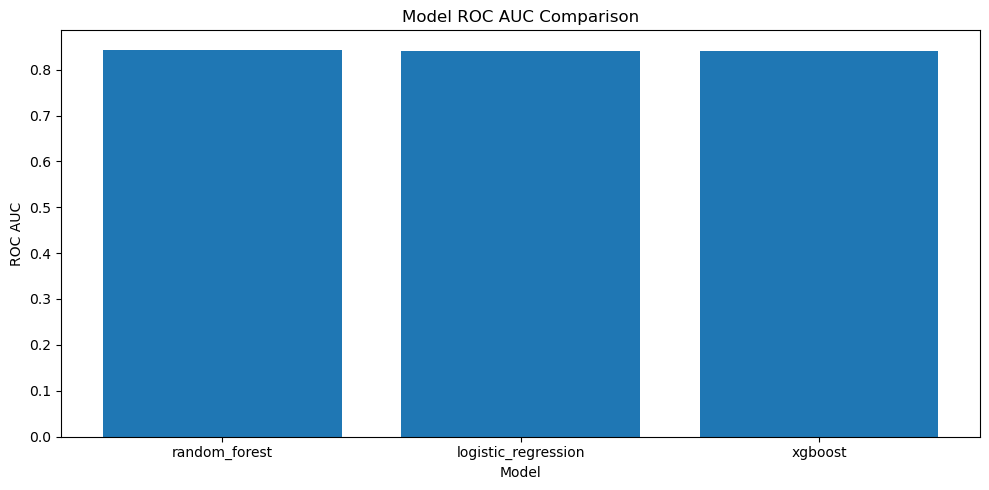

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(model_performance_metrics["model_name"], model_performance_metrics["roc_auc"])
plt.title("Model ROC AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC AUC")
plt.tight_layout()
plt.show()

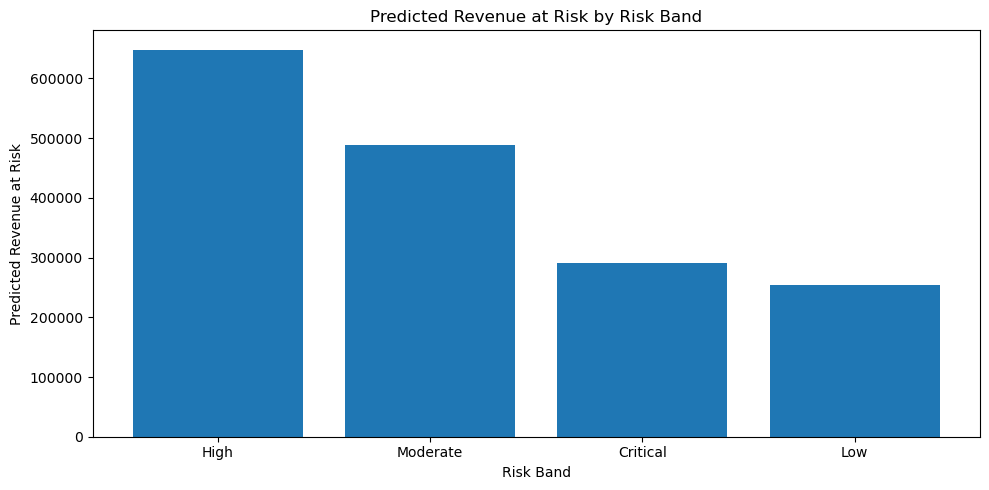

In [21]:
plt.figure(figsize=(10, 5))
plt.bar(risk_revenue_summary["predicted_risk_band"], risk_revenue_summary["total_predicted_revenue_at_risk"])
plt.title("Predicted Revenue at Risk by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Predicted Revenue at Risk")
plt.tight_layout()
plt.show()

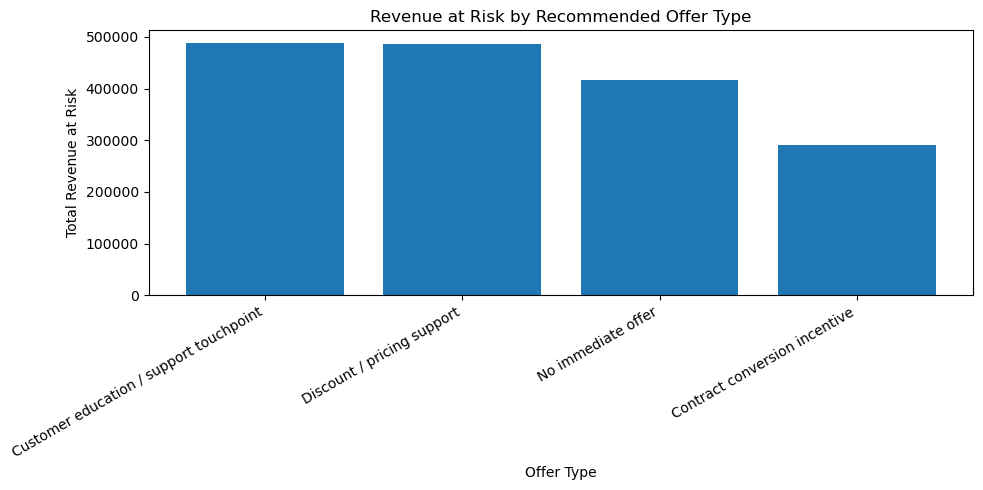

In [22]:
plt.figure(figsize=(10, 5))
plt.bar(playbook_summary["recommended_offer_type"], playbook_summary["total_revenue_at_risk"])
plt.title("Revenue at Risk by Recommended Offer Type")
plt.xlabel("Offer Type")
plt.ylabel("Total Revenue at Risk")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
## 9. Executive Insights

In [23]:
top_model = model_performance_metrics.sort_values("roc_auc", ascending=False).iloc[0]
top_risk_band = risk_revenue_summary.sort_values("total_predicted_revenue_at_risk", ascending=False).iloc[0]
top_customer = customer_predictions.sort_values("retention_priority_score", ascending=False).iloc[0]
top_offer = playbook_summary.sort_values("total_revenue_at_risk", ascending=False).iloc[0]

insights = [
    f"The strongest production candidate is {top_model['model_name']} with a ROC AUC of {top_model['roc_auc']:.4f}, confirming it as the most effective churn classifier in the current pipeline.",
    f"The largest modeled revenue concentration sits in the {top_risk_band['predicted_risk_band']} risk band, representing ${top_risk_band['total_predicted_revenue_at_risk']:,.2f} in predicted revenue at risk.",
    f"The highest-priority individual customer is {top_customer['customerID']}, with a retention priority score of {top_customer['retention_priority_score']:,.2f} and predicted revenue risk of ${top_customer['predicted_revenue_at_risk']:,.2f}.",
    f"The highest-impact retention strategy category is '{top_offer['recommended_offer_type']}', which covers ${top_offer['total_revenue_at_risk']:,.2f} in modeled revenue exposure.",
    f"Leadership should focus retention resources on high-value, high-risk customers with short contract duration and elevated monthly charges, while operationalizing the random forest model as the primary churn scoring engine."
]

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

1. The strongest production candidate is random_forest with a ROC AUC of 0.8435, confirming it as the most effective churn classifier in the current pipeline.
2. The largest modeled revenue concentration sits in the High risk band, representing $648,246.48 in predicted revenue at risk.
3. The highest-priority individual customer is 7216-EWTRS, with a retention priority score of 1,101.32 and predicted revenue risk of $1,101.32.
4. The highest-impact retention strategy category is 'Customer education / support touchpoint', which covers $488,107.26 in modeled revenue exposure.
5. Leadership should focus retention resources on high-value, high-risk customers with short contract duration and elevated monthly charges, while operationalizing the random forest model as the primary churn scoring engine.


In [ ]:
## 10. Export Analytical Outputs

In [24]:
insight_df = pd.DataFrame({"insight": insights})
insight_path = BASE_DIR / "docs" / "executive_insights.csv"
insight_df.to_csv(insight_path, index=False)

analytic_summary_path = BASE_DIR / "docs" / "churn_analytic_summary.xlsx"
with pd.ExcelWriter(analytic_summary_path, engine="openpyxl") as writer:
    dq_profile.to_excel(writer, sheet_name="data_quality_profile", index=False)
    model_performance_metrics.to_excel(writer, sheet_name="model_performance", index=False)
    confusion_matrix_summary.to_excel(writer, sheet_name="confusion_matrix", index=False)
    customer_predictions.to_excel(writer, sheet_name="customer_predictions", index=False)
    customer_risk_segments.to_excel(writer, sheet_name="risk_segments", index=False)
    retention_action_plan.to_excel(writer, sheet_name="retention_action_plan", index=False)
    high_value_at_risk_customers.to_excel(writer, sheet_name="high_value_at_risk", index=False)
    retention_playbook_by_segment.to_excel(writer, sheet_name="retention_playbooks", index=False)

print("Saved:")
print("-", insight_path)
print("-", analytic_summary_path)

Saved:
- /Users/6ixbio/Downloads/customer-churn-command-center/docs/executive_insights.csv
- /Users/6ixbio/Downloads/customer-churn-command-center/docs/churn_analytic_summary.xlsx


In [ ]:
## 11. Executive Summary Output

In [25]:
print(summary_text)

Customer Retention Executive Summary

Total customers analyzed: 7043
Selected production model: random_forest

Predicted churn risk distribution:
- Critical: 356
- High: 1111
- Moderate: 1562
- Low: 4014

Financial exposure:
- Total estimated annual revenue: $5,473,399.20
- Total predicted revenue at risk: $1,681,259.53
- High-risk revenue at risk: $939,229.83

Leadership interpretation:
The retention portfolio shows a concentrated pocket of high-value customer risk that should be addressed through targeted interventions rather than broad campaigns. Priority should be placed on customers with high churn probability, month-to-month contracts, and elevated monthly charges, as these segments represent the greatest near-term revenue exposure.

Recommended strategic actions:
1. Prioritize high-value Critical and High risk customers for immediate retention outreach.
2. Use contract conversion incentives for high-risk month-to-month customers.
3. Deploy onboarding and support interventions fo